# 前置资源说明

* python	>=3.9	3.10	
* cuda cuda12
* torch	>=2.0

算力卡：支持A10/A100/H100、RTX20/30/40系列	、T4/V100部分模型出现NAN、Ascend NPU部分模型出现NAN或算子不支持

# 准备训推环境

In [ ]:
# # install ms-swift
!pip install 'ms-swift[all]' -U

In [2]:
# import some libraries
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

from swift.llm import get_model_tokenizer, load_dataset, get_template, EncodePreprocessor
from swift.utils import get_logger, find_all_linears, get_model_parameter_info, plot_images, seed_everything
from swift.tuners import Swift, LoraConfig
from swift.trainers import Seq2SeqTrainer, Seq2SeqTrainingArguments
from functools import partial

logger = get_logger()
seed_everything(42)

2025-07-16 09:09:01.537673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752656941.563803     500 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752656941.571544     500 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[INFO:swift] Successfully registered `/usr/local/lib/python3.11/dist-packages/swift/llm/dataset/data/dataset_info.json`.
[INFO:swift] Global seed set to 42


42

# 准备模型数据

## 配置训练超参

In [4]:
# Hyperparameters for training
data_seed = 42
max_length = 2048
split_dataset_ratio = 0.01  # Split validation set

system = 'You are a helpful assistant.'
output_dir = 'output'

# lora
lora_rank = 8
lora_alpha = 32

# training_args
training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    learning_rate=1e-4,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_checkpointing=True,
    weight_decay=0.1,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    report_to=['tensorboard'],
    logging_first_step=True,
    save_strategy='steps',
    save_steps=50,
    eval_strategy='steps',
    eval_steps=50,
    gradient_accumulation_steps=16,
    num_train_epochs=1,
    metric_for_best_model='loss',
    save_total_limit=2,
    logging_steps=5,
    dataloader_num_workers=1,
    data_seed=data_seed,
)

In [5]:
num_proc = 4  # The number of processes for data loading.
# The following two parameters are used to override the placeholders in the self-cognition dataset.
model_name = ['小黄', 'Xiao Huang']  # The Chinese name and English name of the model
model_author = ['魔搭', 'ModelScope']  # The Chinese name and English name of the model author

output_dir = os.path.abspath(os.path.expanduser(output_dir))
logger.info(f'output_dir: {output_dir}')

[INFO:swift] output_dir: /kaggle/working/output


## 加载模型参数

In [6]:
model, tokenizer = get_model_tokenizer(
    model_id_or_path = '/kaggle/input/qwen-3/transformers/8b/1',
    model_type = "qwen3",
    device_map = "auto",
    torch_dtype="bfloat16"
)

logger.info(f'model_info: {model.model_info}')
template = get_template(model.model_meta.template, tokenizer, default_system=system, max_length=max_length)
template.set_mode('train')

[INFO:swift] Loading the model using model_dir: /kaggle/input/qwen-3/transformers/8b/1
[INFO:swift] model_kwargs: {'device_map': 'auto'}


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

[INFO:swift] model_info: ModelInfo(model_type='qwen3', model_dir='/kaggle/input/qwen-3/transformers/8b/1', torch_dtype='bfloat16', max_model_len=40960, quant_method=None, quant_bits=None, rope_scaling=None, config=Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 12288,
  "max_position_embeddings": 40960,
  "max_window_layers": 36,
  "model_type": "qwen3",
  "num_attention_heads": 32,
  "num_hidden_layers": 36,
  "num_key_value_heads": 8,
  "pad_token_id": 151643,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000,
  "sliding_window": null,
  "tie_word_embeddings": false,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "use_sliding_window": false,
  "vocab_size": 151936
}
, task_type='causal

In [ ]:
from swift.llm import PtEngine, RequestConfig, InferRequest

# 加载推理引擎
engine = PtEngine(model, max_batch_size=2)
request_config = RequestConfig(max_tokens=512, temperature=0)

# 这里使用了2个infer_request来展示batch推理
infer_requests = [
    InferRequest(messages=[{'role': 'user', 'content': 'who are you?'}]),
    InferRequest(messages=[{'role': 'user', 'content': '浙江的省会在哪？'},
                           {'role': 'assistant', 'content': '浙江省的省会是杭州。'},
                           {'role': 'user', 'content': '这里有什么好玩的地方'},]),
]
resp_list = engine.infer(infer_requests, request_config)
query0 = infer_requests[0].messages[0]['content']
print(f'response0: {resp_list[0].choices[0].message.content}')
print(f'response1: {resp_list[1].choices[0].message.content}')

In [7]:
# Obtain the model and template, and add a trainable Lora layer on the model.

target_modules = find_all_linears(model)
lora_config = LoraConfig(task_type='CAUSAL_LM', r=lora_rank, lora_alpha=lora_alpha,
                         target_modules=target_modules)
model = Swift.prepare_model(model, lora_config)
logger.info(f'lora_config: {lora_config}')

# Print model structure and trainable parameters.
logger.info(f'model: {model}')
model_parameter_info = get_model_parameter_info(model)
logger.info(f'model_parameter_info: {model_parameter_info}')

[INFO:swift] lora_config: LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path='/kaggle/input/qwen-3/transformers/8b/1', revision=None, inference_mode=False, r=8, target_modules={'q_proj', 'down_proj', 'v_proj', 'gate_proj', 'o_proj', 'k_proj', 'up_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, lora_dtype=None, lorap_lr_ratio=None, lorap_emb_lr=1e-06)
[INFO:swift] model: PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
       

## 加载训练数据

In [8]:
# Download and load the dataset, split it into a training set and a validation set,
# dataset
dataset = ['AI-ModelScope/alpaca-gpt4-data-zh#500', 'AI-ModelScope/alpaca-gpt4-data-en#500',
           'swift/self-cognition#500']  # dataset_id or dataset_path
# and encode the text data into tokens.
train_dataset, val_dataset = load_dataset(dataset, split_dataset_ratio=split_dataset_ratio, num_proc=num_proc,
        model_name=model_name, model_author=model_author, seed=data_seed)

logger.info(f'train_dataset: {train_dataset}')
logger.info(f'val_dataset: {val_dataset}')
logger.info(f'train_dataset[0]: {train_dataset[0]}')

train_dataset = EncodePreprocessor(template=template)(train_dataset, num_proc=num_proc)
val_dataset = EncodePreprocessor(template=template)(val_dataset, num_proc=num_proc)
logger.info(f'encoded_train_dataset[0]: {train_dataset[0]}')

# Print a sample
template.print_inputs(train_dataset[0])

[INFO:swift] SelfCognitionPreprocessor has been successfully configured with name: ['小黄', 'Xiao Huang'], author: ['魔搭', 'ModelScope'].
[INFO:swift] Downloading the dataset from ModelScope, dataset_id: AI-ModelScope/alpaca-gpt4-data-zh
[INFO:swift] Downloading the dataset from ModelScope, dataset_id: AI-ModelScope/alpaca-gpt4-data-en
[INFO:swift] Downloading the dataset from ModelScope, dataset_id: swift/self-cognition
[WARNING:swift] dataset_sample:499 is greater than len(dataset):107, repeated sampling will be performed.
[INFO:swift] train_dataset: Dataset({
    features: ['messages'],
    num_rows: 1489
})
[INFO:swift] val_dataset: Dataset({
    features: ['messages'],
    num_rows: 11
})
[INFO:swift] train_dataset[0]: {'messages': [{'role': 'user', 'content': '保持健康的三个提示。'}, {'role': 'assistant', 'content': '以下是保持健康的三个提示：\n\n1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。\n\n2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。\n\n3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时

Map (num_proc=4):   0%|          | 0/1489 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/11 [00:00<?, ? examples/s]

[INFO:swift] encoded_train_dataset[0]: {'input_ids': [151644, 8948, 198, 2610, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 100662, 108136, 101124, 45139, 1773, 151645, 198, 151644, 77091, 198, 114566, 100662, 108136, 101124, 45139, 48443, 16, 13, 220, 100662, 101099, 99600, 1773, 101922, 99190, 102618, 106214, 101079, 3837, 29524, 111261, 5373, 107530, 57191, 107140, 3837, 26232, 101902, 114718, 99722, 3837, 101138, 105640, 101102, 90395, 105767, 101940, 107235, 3407, 17, 13, 4891, 251, 229, 99967, 104579, 1773, 101922, 105086, 104838, 9370, 104451, 5373, 104618, 5373, 35987, 100203, 52853, 33108, 105349, 104982, 99285, 9370, 107151, 102153, 3837, 101153, 44636, 100443, 5373, 44636, 105349, 33108, 101130, 101083, 3837, 23031, 100662, 108136, 104579, 100784, 3407, 18, 13, 10236, 251, 94, 101519, 103119, 1773, 105552, 113357, 99722, 107940, 3837, 113459, 101922, 50511, 101907, 220, 22, 12, 23, 58230, 237, 13343, 9370, 105552, 1773, 104205, 105552, 105767, 106104, 101950, 3

## 开启模型训练

In [9]:
# Get the trainer and start the training.
model.enable_input_require_grads()  # Compatible with gradient checkpointing
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    data_collator=template.data_collator,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    template=template,
)

trainer.train()

last_model_checkpoint = trainer.state.last_model_checkpoint
logger.info(f'last_model_checkpoint: {last_model_checkpoint}')

/usr/local/lib/python3.11/dist-packages/swift/trainers/mixin.py:95: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  super().__init__(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
[INFO:swift] use_reentrant: True
Train:   1%|          | 1/94 [00:52<1:20:44, 52.09s/it]

{'loss': 2.2161665, 'token_acc': 0.5665529, 'grad_norm': 1.91455138, 'learning_rate': 2e-05, 'memory(GiB)': 17.07, 'train_speed(iter/s)': 0.018981, 'epoch': 0.01, 'global_step/max_steps': '1/94', 'percentage': '1.06%', 'elapsed_time': '52s', 'remaining_time': '1h 20m 44s'}


Train:   5%|▌         | 5/94 [04:21<1:15:55, 51.19s/it]

{'loss': 2.04263401, 'token_acc': 0.63904853, 'grad_norm': 1.74650323, 'learning_rate': 0.0001, 'memory(GiB)': 17.52, 'train_speed(iter/s)': 0.019079, 'epoch': 0.05, 'global_step/max_steps': '5/94', 'percentage': '5.32%', 'elapsed_time': '4m 21s', 'remaining_time': '1h 17m 34s'}


Train:  11%|█         | 10/94 [08:23<1:05:16, 46.62s/it]

...

{'loss': 1.05972776, 'token_acc': 0.7008052, 'grad_norm': 0.57800734, 'learning_rate': 5e-07, 'memory(GiB)': 17.67, 'train_speed(iter/s)': 0.019482, 'epoch': 0.97, 'global_step/max_steps': '90/94', 'percentage': '95.74%', 'elapsed_time': '1h 16m 59s', 'remaining_time': '3m 25s'}


Val: 100%|██████████| 11/11 [00:14<00:00,  1.36s/it]/it]


{'eval_loss': 1.30771101, 'eval_runtime': 16.6938, 'eval_samples_per_second': 0.659, 'eval_steps_per_second': 0.659, 'epoch': 1.0, 'global_step/max_steps': '94/94', 'percentage': '100.00%', 'elapsed_time': '1h 20m 1s', 'remaining_time': '0s'}


[INFO:swift] Saving model checkpoint to /kaggle/working/output/checkpoint-94
Train: 100%|██████████| 94/94 [1:20:02<00:00, 51.09s/it]
[INFO:swift] last_model_checkpoint: /kaggle/working/output/checkpoint-94


{'train_runtime': 4802.6604, 'train_samples_per_second': 0.31, 'train_steps_per_second': 0.02, 'train_loss': 1.27183658, 'epoch': 1.0, 'global_step/max_steps': '94/94', 'percentage': '100.00%', 'elapsed_time': '1h 20m 2s', 'remaining_time': '0s'}


[INFO:swift] images_dir: /kaggle/working/output/images


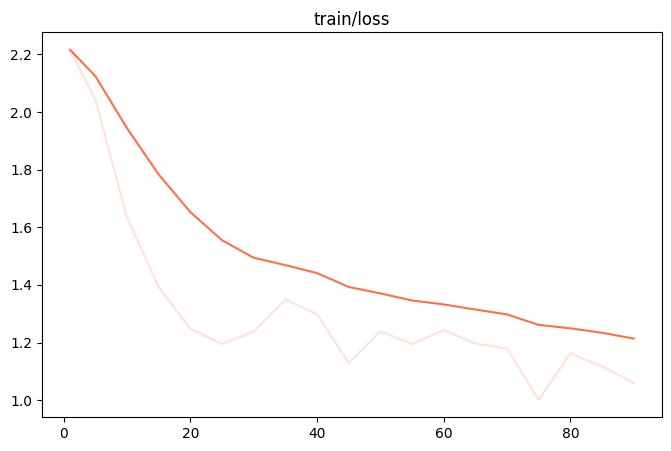

In [10]:
# Visualize the training loss.
# You can also use the TensorBoard visualization interface during training by entering
# `tensorboard --logdir '{output_dir}/runs'` at the command line.
images_dir = os.path.join(output_dir, 'images')
logger.info(f'images_dir: {images_dir}')
plot_images(images_dir, training_args.logging_dir, ['train/loss'], 0.9)  # save images

# Read and display the image.
# The light yellow line represents the actual loss value,
# while the yellow line represents the loss value smoothed with a smoothing factor of 0.9.
from IPython.display import display
from PIL import Image
image = Image.open(os.path.join(images_dir, 'train_loss.png'))
display(image)

# 模型推理验证

In [16]:
# import some libraries
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

from swift.llm import InferEngine, InferRequest, PtEngine, RequestConfig, get_template

In [19]:
# Hyperparameters for inference
last_model_checkpoint = 'output/checkpoint-xxx'

system = 'You are a helpful assistant.'
infer_backend = 'pt'

# generation_config
max_new_tokens = 512
temperature = 0
stream = True

In [17]:
# Get model and template, and load LoRA weights.
engine = PtEngine(
    model_id_or_path = '/kaggle/input/qwen-3/transformers/8b/1',
    model_type = "qwen3",
    device_map = "auto",
    torch_dtype="bfloat16",
    adapters=[last_model_checkpoint]
)

template = get_template(engine.model_meta.template, engine.processor, default_system=system)
# You can modify the `default_template` directly here, or pass it in during `engine.infer`.
engine.default_template = template

[INFO:swift] Loading the model using model_dir: /kaggle/input/qwen-3/transformers/8b/1
[INFO:swift] model_kwargs: {'device_map': 'auto'}


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

[INFO:swift] Loading the model using model_dir: /kaggle/working/output/checkpoint-94
[INFO:swift] Create the default_template for the infer_engine
[INFO:swift] default_system: None
[INFO:swift] max_length: 40960
[INFO:swift] response_prefix: ''
[INFO:swift] agent_template: hermes
[INFO:swift] default_system: 'You are a helpful assistant.'
[INFO:swift] max_length: 40960
[INFO:swift] response_prefix: ''
[INFO:swift] agent_template: hermes


In [ ]:
query_list = [
    'who are you?',
    "What should I do if I can't sleep at night?",
    '你是谁训练的？',
]

def infer_stream(engine: InferEngine, infer_request: InferRequest):
    request_config = RequestConfig(max_tokens=max_new_tokens, temperature=temperature, stream=True)
    gen_list = engine.infer([infer_request], request_config)
    query = infer_request.messages[0]['content']
    print(f'query: {query}\nresponse: ', end='')
    for resp in gen_list[0]:
        if resp is None:
            continue
        print(resp.choices[0].delta.content, end='', flush=True)
    print()

def infer(engine: InferEngine, infer_request: InferRequest):
    request_config = RequestConfig(max_tokens=max_new_tokens, temperature=temperature)
    resp_list = engine.infer([infer_request], request_config)
    query = infer_request.messages[0]['content']
    response = resp_list[0].choices[0].message.content
    print(f'query: {query}')
    print(f'response: {response}')

infer_func = infer_stream if stream else infer
for query in query_list:
    infer_func(engine, InferRequest(messages=[{'role': 'user', 'content': query}]))
    print('-' * 50)

Exception in thread Thread-17 (<lambda>):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/swift/llm/infer/infer_engine/infer_engine.py", line 76, in <lambda>
    thread = Thread(target=lambda: loop.run_until_complete(_run_async_iter()))
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/asyncio/base_events.py", line 630, in run_until_complete
    self._check_running()
  File "/usr/lib/python3.11/asyncio/base_events.py", line 589, in _check_running
    raise RuntimeError('This event loop is already running')
RuntimeError: This event loop is already running


query: who are you?
response: 